## 1️⃣ Conexión a BigQuery y carga de datos
Cargamos la vista maestra construida en la Fase 1 (2.163 ofertas, 26 columnas) directamente desde BigQuery.

In [1]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

proyecto = 'tfm-mercado-laboral-datos'
client = bigquery.Client(project=proyecto)

query = """
SELECT *
FROM `tfm-mercado-laboral-datos.mercado_laboral_datos.vista_maestra_mercado_laboral`
"""

df = client.query(query).to_dataframe()
df.shape

(2163, 26)

## 2️⃣ Preparación de variables estructuradas
Reconstruimos modalidad de trabajo, nivel de experiencia y salario (ya validados en la Fase 2), añadimos el número de skills técnicas por oferta a partir del diccionario de la Fase 3, y derivamos la industria principal de cada oferta — resolviendo por el camino un problema real de formato en ese campo.

In [2]:
df['remote_allowed'].value_counts(dropna=False)

,count
remote_allowed,
NaN,1520
1.0,643


In [3]:
df['modalidad_remoto'] = df['remote_allowed'].map({1.0: 'Remoto'}).fillna('No especificado')
df['modalidad_remoto'].value_counts()

,count
modalidad_remoto,
No especificado,1520
Remoto,643


In [4]:
df['formatted_experience_level'].value_counts(dropna=False)

,count
formatted_experience_level,
Mid-Senior level,1040
None,631
Entry level,275
Associate,151
Director,32
Internship,27
Executive,7


In [5]:
df['formatted_experience_level'] = df['formatted_experience_level'].fillna('No especificado')
df['formatted_experience_level'].value_counts()

,count
formatted_experience_level,
Mid-Senior level,1040
No especificado,631
Entry level,275
Associate,151
Director,32
Internship,27
Executive,7


In [6]:
df['pay_period'].value_counts(dropna=False)

,count
pay_period,
None,1498
YEARLY,457
HOURLY,203
MONTHLY,5


In [7]:
factor_anual = {'YEARLY': 1, 'MONTHLY': 12, 'HOURLY': 2080}
df['factor_anual'] = df['pay_period'].map(factor_anual)

df['salario_min_anual'] = df['min_salary'] * df['factor_anual']
df['salario_max_anual'] = df['max_salary'] * df['factor_anual']

df[['pay_period', 'min_salary', 'factor_anual', 'salario_min_anual']].dropna().head(10)

,pay_period,min_salary,factor_anual,salario_min_anual
5,YEARLY,80000.00,1.0,80000.0
7,YEARLY,68640.00,1.0,68640.0
13,YEARLY,121000.00,1.0,121000.0
14,YEARLY,130000.00,1.0,130000.0
15,YEARLY,90000.00,1.0,90000.0
16,YEARLY,80000.00,1.0,80000.0
20,YEARLY,65000.00,1.0,65000.0
23,YEARLY,150000.00,1.0,150000.0
24,YEARLY,45300.00,1.0,45300.0
30,HOURLY,35.68,2080.0,74214.4


In [8]:
df[['salario_min_anual', 'salario_max_anual']].describe()

,salario_min_anual,salario_max_anual
count,622.000000,6.220000e+02
mean,113876.646158,1.775830e+05
std,42871.019370,5.458220e+05
min,30.000000,3.500000e+01
25%,83200.000000,1.144000e+05
50%,110000.000000,1.456000e+05
75%,140000.000000,1.872000e+05
max,400000.000000,1.366560e+07


In [9]:
df[(df['salario_min_anual'] < 1000) | (df['salario_max_anual'] > 500000)][
    ['title', 'pay_period', 'min_salary', 'max_salary', 'salario_min_anual', 'salario_max_anual']
]

,title,pay_period,min_salary,max_salary,salario_min_anual,salario_max_anual
41,Business Analyst 24-02965,YEARLY,30.0,35.0,30.0,35.0
196,Sr. Data Engineer,YEARLY,70.0,80.0,70.0,80.0
244,Data Engineer,HOURLY,65.0,6570.0,135200.0,13665600.0
481,"ML Engineer L5, LLM Application Frameworks, Ma...",YEARLY,100000.0,720000.0,100000.0,720000.0
635,Data Scientist Intern (Monetization Product an...,YEARLY,45.0,45.0,45.0,45.0
845,Information Technology Business Analyst,YEARLY,60.0,65.0,60.0,65.0
1090,Finance Senior Oracle Fusion Business Analyst,YEARLY,150.0,150.0,150.0,150.0
1327,Full Time - Financial Business Analyst with Re...,YEARLY,50.0,55.0,50.0,55.0
1445,Vice President of Data Engineering,YEARLY,400000.0,600000.0,400000.0,600000.0
1692,Java-Big Data Architect,YEARLY,75.0,85.0,75.0,85.0


In [10]:
df.loc[(df['salario_min_anual'] < 1000) | (df['salario_min_anual'] > 1000000), 'salario_min_anual'] = None
df.loc[(df['salario_max_anual'] < 1000) | (df['salario_max_anual'] > 1000000), 'salario_max_anual'] = None

df[['salario_min_anual', 'salario_max_anual']].describe()

,salario_min_anual,salario_max_anual
count,614.000000,613.000000
mean,115359.485195,157896.340538
std,41117.803429,65093.008124
min,37315.200000,47840.000000
25%,84300.000000,114400.000000
50%,110000.000000,145600.000000
75%,141080.000000,187200.000000
max,400000.000000,720000.000000


In [11]:
import re

def limpiar_texto_ligero(texto):
    if texto is None:
        return ""
    texto = re.sub(r'([a-z])([A-Z])', r'\1 \2', texto)
    return texto.lower()

df['descripcion_limpia'] = df['description'].apply(limpiar_texto_ligero)

In [12]:
diccionario_skills = {
    'Python': [r'\bpython\b'],
    'SQL': [r'\bsql\b'],
    'R': [r'\br\b'],
    'Java': [r'\bjava\b'],
    'Scala': [r'\bscala\b'],
    'VBA': [r'\bvba\b'],
    'Excel': [r'\bexcel\b'],
    'Power BI': [r'\bpower\s?bi\b'],
    'Tableau': [r'\btableau\b'],
    'Looker': [r'\blooker\b'],
    'Qlik': [r'\bqlik\b'],
    'SAP': [r'\bsap\b'],
    'Salesforce': [r'\bsalesforce\b'],
    'Alteryx': [r'\balteryx\b'],
    'AWS': [r'\baws\b'],
    'Azure': [r'\bazure\b'],
    'Google Cloud': [r'\bgcp\b', r'\bgoogle cloud\b'],
    'Snowflake': [r'\bsnowflake\b'],
    'Redshift': [r'\bredshift\b'],
    'BigQuery': [r'\bbigquery\b', r'\bbig query\b'],
    'Databricks': [r'\bdatabricks\b'],
    'Spark': [r'\bspark\b'],
    'Hadoop': [r'\bhadoop\b'],
    'Kafka': [r'\bkafka\b'],
    'Airflow': [r'\bairflow\b'],
    'ETL': [r'\betl\b'],
    'MySQL': [r'\bmysql\b'],
    'PostgreSQL': [r'\bpostgresql\b', r'\bpostgres\b'],
    'MongoDB': [r'\bmongodb\b'],
    'NoSQL': [r'\bnosql\b'],
    'Machine Learning': [r'\bmachine learning\b'],
    'Deep Learning': [r'\bdeep learning\b'],
    'TensorFlow': [r'\btensorflow\b'],
    'PyTorch': [r'\bpytorch\b'],
    'Scikit-learn': [r'\bscikit-learn\b', r'\bsklearn\b'],
    'Pandas': [r'\bpandas\b'],
    'NumPy': [r'\bnumpy\b'],
    'Git': [r'\bgit\b'],
    'Docker': [r'\bdocker\b'],
    'Kubernetes': [r'\bkubernetes\b'],
    'Jira': [r'\bjira\b'],
    'Agile': [r'\bagile\b'],
    'Scrum': [r'\bscrum\b'],
    'DAX': [r'\bdax\b'],
}

def detectar_skills(texto, diccionario):
    encontradas = []
    for skill, patrones in diccionario.items():
        for patron in patrones:
            if re.search(patron, texto):
                encontradas.append(skill)
                break
    return encontradas

df['skills_detectadas'] = df['descripcion_limpia'].apply(lambda t: detectar_skills(t, diccionario_skills))

In [13]:
diccionario_skills['R'] = [r'\br\b(?!\s*&\s*d)']
diccionario_skills['C++'] = [r'c\+\+']

df['skills_detectadas'] = df['descripcion_limpia'].apply(lambda t: detectar_skills(t, diccionario_skills))

In [14]:
df['num_skills'] = df['skills_detectadas'].apply(len)
df['num_skills'].describe()

,num_skills
count,2163.000000
mean,4.081368
std,3.308224
min,0.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,19.000000


In [15]:
df['skills_detectadas'].explode().value_counts().head(10)

,count
skills_detectadas,
SQL,1135
Python,943
Machine Learning,517
Agile,491
AWS,426
Excel,404
Azure,382
Power BI,358
ETL,352


In [16]:
df['industria_principal'] = df['industrias_lista'].apply(lambda lista: lista[0] if lista is not None and len(lista) > 0 else None)
df['industria_principal'].value_counts(dropna=False)

,count
industria_principal,
I,730
S,375
F,232
H,145
B,139
T,121
M,58
R,49
A,47


In [17]:
print(df['industrias_lista'].iloc[0])
print(type(df['industrias_lista'].iloc[0]))

Software Development, Technology, Information and Internet, Entertainment Providers
<class 'str'>


In [18]:
df['industrias_lista'].apply(lambda x: ',' in x if isinstance(x, str) else False).sum()

np.int64(534)

In [19]:
df[df['industrias_lista'].apply(lambda x: isinstance(x, str) and ',' in x)]['industrias_lista'].head(10)

,industrias_lista
0,"Software Development, Technology, Information ..."
5,"Financial Services, Accounting, IT Services an..."
14,"Information Services, Technology, Information ..."
16,"Business Consulting and Services, Higher Educa..."
17,"Technology, Information and Internet"
19,"Construction, IT System Data Services, Enginee..."
20,"Hospitals and Health Care, Insurance, Wellness..."
23,"Information Services, Technology, Information ..."
24,"Software Development, Business Consulting and ..."
25,"Technology, Information and Media"


In [20]:
df['industria_principal'] = df['industrias_lista'].apply(lambda x: x.split(',')[0].strip() if isinstance(x, str) else None)
df['industria_principal'].value_counts(dropna=False)

,count
industria_principal,
IT Services and IT Consulting,516
Software Development,262
Financial Services,219
Hospitals and Health Care,110
Staffing and Recruiting,93
...,...
Civil Engineering,1
Mining,1
Shipbuilding,1


In [21]:
umbral = 20
conteo_industrias = df['industria_principal'].value_counts()
industrias_frecuentes = conteo_industrias[conteo_industrias >= umbral].index

df['industria_principal'] = df['industria_principal'].apply(
    lambda x: x if x in industrias_frecuentes else 'Otras'
)
df['industria_principal'].value_counts(dropna=False)

,count
industria_principal,
IT Services and IT Consulting,516
Otras,353
Software Development,262
Financial Services,219
Hospitals and Health Care,110
Staffing and Recruiting,93
Technology,75
Insurance,66
Information Services,65


## 3️⃣ Random Forest: prediciendo el rol sin leer el texto
Entrenamos un Random Forest para predecir la categoría de rol usando solo industria, modalidad, experiencia y número de skills, y lo evaluamos con matriz de confusión, importancia de variables (por impureza y por permutación) y validación cruzada.

In [22]:
from sklearn.feature_extraction import DictVectorizer

columnas_features = ['industria_principal', 'modalidad_remoto', 'formatted_experience_level', 'num_skills']
df_modelo = df[columnas_features + ['categoria_rol']].dropna()

vectorizador = DictVectorizer(sparse=False)
X = vectorizador.fit_transform(df_modelo[columnas_features].to_dict('records'))
y = df_modelo['categoria_rol']

print(X.shape)
print(vectorizador.get_feature_names_out())

(2163, 32)
['formatted_experience_level=Associate'
 'formatted_experience_level=Director'
 'formatted_experience_level=Entry level'
 'formatted_experience_level=Executive'
 'formatted_experience_level=Internship'
 'formatted_experience_level=Mid-Senior level'
 'formatted_experience_level=No especificado'
 'industria_principal=Advertising Services' 'industria_principal=Banking'
 'industria_principal=Biotechnology Research'
 'industria_principal=Business Consulting and Services'
 'industria_principal=Defense and Space Manufacturing'
 'industria_principal=Entertainment Providers'
 'industria_principal=Financial Services'
 'industria_principal=Government Administration'
 'industria_principal=Higher Education'
 'industria_principal=Hospitals and Health Care'
 'industria_principal=IT Services and IT Consulting'
 'industria_principal=Information Services'
 'industria_principal=Information Technology & Services'
 'industria_principal=Insurance' 'industria_principal=Manufacturing'
 'industria_p

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)

(1730, 32) (433, 32)


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(classification_report(y_val, y_pred))

Accuracy: 0.4596 (45.96%)
                           precision    recall  f1-score   support

   BI Analyst / Developer       0.22      0.34      0.27        38
         Business Analyst       0.66      0.66      0.66       111
             Data Analyst       0.57      0.35      0.44        82
           Data Architect       0.18      0.31      0.23        26
            Data Engineer       0.57      0.41      0.47        79
           Data Scientist       0.51      0.51      0.51        70
Machine Learning Engineer       0.20      0.30      0.24        27

                 accuracy                           0.46       433
                macro avg       0.42      0.41      0.40       433
             weighted avg       0.51      0.46      0.47       433



In [25]:
!pip install -q kaleido==0.2.1
import plotly.io as pio
pio.renderers.default = "png"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.5 MB/s eta 0:00:00


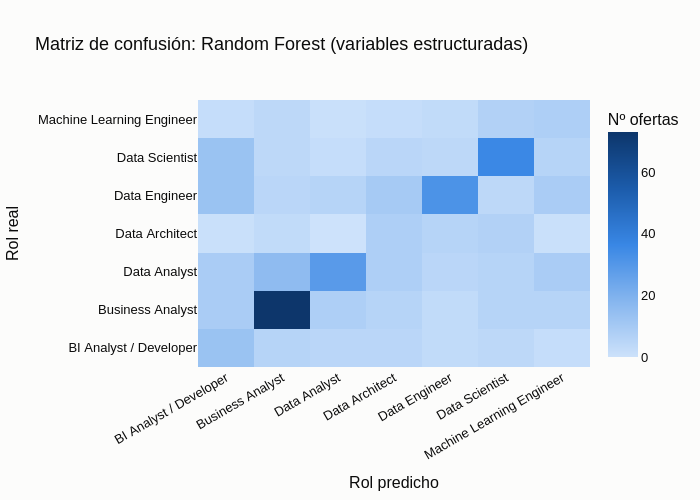

In [26]:
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix

etiquetas = sorted(y.unique())
matriz_confusion = confusion_matrix(y_val, y_pred, labels=etiquetas)
matriz_confusion_df = pd.DataFrame(matriz_confusion, index=etiquetas, columns=etiquetas)

colorscale_azul = [
    [0.0, '#cde2fb'],
    [0.25, '#86b6ef'],
    [0.5, '#3987e5'],
    [0.75, '#1c5cab'],
    [1.0, '#0d366b'],
]

fig = go.Figure(data=go.Heatmap(
    z=matriz_confusion_df.values,
    x=matriz_confusion_df.columns,
    y=matriz_confusion_df.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='Nº ofertas'),
    hovertemplate='Real: %{y}<br>Predicho: %{x}<br>%{z} ofertas<extra></extra>',
))

fig.update_layout(
    title='Matriz de confusión: Random Forest (variables estructuradas)',
    xaxis_title='Rol predicho',
    yaxis_title='Rol real',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180, b=120),
)
fig.update_xaxes(tickangle=-30)
fig.show()

In [27]:
importancias = pd.DataFrame({
    'variable': vectorizador.get_feature_names_out(),
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=False)

importancias.head(15)

,variable,importancia
31,num_skills,0.447507
2,formatted_experience_level=Entry level,0.041740
5,formatted_experience_level=Mid-Senior level,0.033878
29,modalidad_remoto=No especificado,0.032047
6,formatted_experience_level=No especificado,0.031716
17,industria_principal=IT Services and IT Consulting,0.031226
30,modalidad_remoto=Remoto,0.030369
25,industria_principal=Software Development,0.030002
22,industria_principal=Otras,0.027774
13,industria_principal=Financial Services,0.024092


In [28]:
from sklearn.inspection import permutation_importance

resultado_permutacion = permutation_importance(
    rf_model, X_val, y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancias_permutacion = pd.DataFrame({
    'variable': vectorizador.get_feature_names_out(),
    'importancia': resultado_permutacion.importances_mean
}).sort_values('importancia', ascending=False)

importancias_permutacion.head(15)

,variable,importancia
31,num_skills,0.228176
2,formatted_experience_level=Entry level,0.067436
17,industria_principal=IT Services and IT Consulting,0.019169
13,industria_principal=Financial Services,0.018707
5,formatted_experience_level=Mid-Senior level,0.017783
25,industria_principal=Software Development,0.014088
26,industria_principal=Staffing and Recruiting,0.012240
6,formatted_experience_level=No especificado,0.011778
28,industria_principal=Telecommunications,0.006005
12,industria_principal=Entertainment Providers,0.005543


In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

scores_cv = cross_val_score(rf_cv, X, y, cv=skf, scoring='accuracy')

print("Accuracy por fold:", scores_cv)
print(f"Accuracy media: {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")

Accuracy por fold: [0.41108545 0.45265589 0.44341801 0.40046296 0.37037037]
Accuracy media: 0.4156 ± 0.0298


### Modelo complementario: añadiendo el salario
Repetimos el proceso incluyendo el salario, restringido a las 613 ofertas donde el dato es real, para no inventar valores sobre el 72% restante.

In [30]:
df['salario_mediana_oferta'] = (df['salario_min_anual'] + df['salario_max_anual']) / 2

columnas_features_v2 = columnas_features + ['salario_mediana_oferta']
df_modelo_salario = df[columnas_features_v2 + ['categoria_rol']].dropna()

print(df_modelo_salario.shape)

(613, 6)


In [31]:
vectorizador_salario = DictVectorizer(sparse=False)
X_salario = vectorizador_salario.fit_transform(df_modelo_salario[columnas_features_v2].to_dict('records'))
y_salario = df_modelo_salario['categoria_rol']

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_salario, y_salario,
    test_size=0.2,
    random_state=42,
    stratify=y_salario
)

rf_salario = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_salario.fit(X_train_s, y_train_s)
y_pred_s = rf_salario.predict(X_val_s)
accuracy_s = accuracy_score(y_val_s, y_pred_s)

print(f"Accuracy (con salario, n={len(df_modelo_salario)}): {accuracy_s:.4f} ({accuracy_s*100:.2f}%)")
print(classification_report(y_val_s, y_pred_s))

Accuracy (con salario, n=613): 0.3740 (37.40%)
                           precision    recall  f1-score   support

   BI Analyst / Developer       0.31      0.42      0.36        12
         Business Analyst       0.29      0.26      0.27        27
             Data Analyst       0.36      0.43      0.39        23
           Data Architect       0.29      0.40      0.33         5
            Data Engineer       0.43      0.38      0.40        24
           Data Scientist       0.59      0.45      0.51        22
Machine Learning Engineer       0.30      0.30      0.30        10

                 accuracy                           0.37       123
                macro avg       0.37      0.38      0.37       123
             weighted avg       0.39      0.37      0.38       123



In [32]:
resultado_permutacion_salario = permutation_importance(
    rf_salario, X_val_s, y_val_s,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancias_salario = pd.DataFrame({
    'variable': vectorizador_salario.get_feature_names_out(),
    'importancia': resultado_permutacion_salario.importances_mean
}).sort_values('importancia', ascending=False)

importancias_salario.head(10)

,variable,importancia
32,salario_mediana_oferta,0.097561
31,num_skills,0.049593
30,modalidad_remoto=Remoto,0.012195
17,industria_principal=IT Services and IT Consulting,0.012195
12,industria_principal=Entertainment Providers,0.008130
29,modalidad_remoto=No especificado,0.008130
0,formatted_experience_level=Associate,0.005691
7,industria_principal=Advertising Services,0.001626
9,industria_principal=Biotechnology Research,0.000000
24,industria_principal=Retail,0.000000


In [33]:
scores_cv_salario = cross_val_score(rf_salario, X_salario, y_salario, cv=skf, scoring='accuracy')

print("Accuracy por fold:", scores_cv_salario)
print(f"Accuracy media: {scores_cv_salario.mean():.4f} ± {scores_cv_salario.std():.4f}")

Accuracy por fold: [0.3902439  0.51219512 0.45528455 0.45901639 0.36885246]
Accuracy media: 0.4371 ± 0.0516


### Ajuste de hiperparámetros (GridSearchCV)
Buscamos la mejor combinación de hiperparámetros optimizando F1 macro, y la comparamos con el modelo base antes de adoptarla.

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print(f"Mejor F1 macro (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1 macro (CV): 0.3582


In [35]:
from sklearn.metrics import f1_score

mejor_modelo = grid_search.best_estimator_
y_pred_tuned = mejor_modelo.predict(X_val)

accuracy_tuned = accuracy_score(y_val, y_pred_tuned)
f1_macro_tuned = f1_score(y_val, y_pred_tuned, average='macro')
f1_macro_baseline = f1_score(y_val, y_pred, average='macro')

print(f"Modelo base:     accuracy={accuracy:.4f}, F1 macro={f1_macro_baseline:.4f}")
print(f"Modelo ajustado: accuracy={accuracy_tuned:.4f}, F1 macro={f1_macro_tuned:.4f}")
print()
print(classification_report(y_val, y_pred_tuned))

Modelo base:     accuracy=0.4596, F1 macro=0.4016
Modelo ajustado: accuracy=0.4734, F1 macro=0.4063

                           precision    recall  f1-score   support

   BI Analyst / Developer       0.27      0.39      0.32        38
         Business Analyst       0.61      0.76      0.68       111
             Data Analyst       0.64      0.30      0.41        82
           Data Architect       0.21      0.31      0.25        26
            Data Engineer       0.46      0.42      0.44        79
           Data Scientist       0.55      0.47      0.51        70
Machine Learning Engineer       0.21      0.26      0.23        27

                 accuracy                           0.47       433
                macro avg       0.42      0.42      0.41       433
             weighted avg       0.50      0.47      0.47       433



## 4️⃣ K-Means: ¿surgen los roles de forma natural?
Escalamos las variables y exploramos el número óptimo de clústeres (codo y silhouette) antes de agrupar las ofertas sin decirle al algoritmo el rol real, para comprobar después cuánto coinciden los grupos con los roles conocidos.

In [36]:
from sklearn.preprocessing import StandardScaler

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

print(X_escalado.mean(axis=0)[:5])
print(X_escalado.std(axis=0)[:5])

[-1.10991506e-15  3.25226567e-16  2.87898333e-16  1.92704280e-16
 -3.04515749e-16]
[1. 1. 1. 1. 1.]


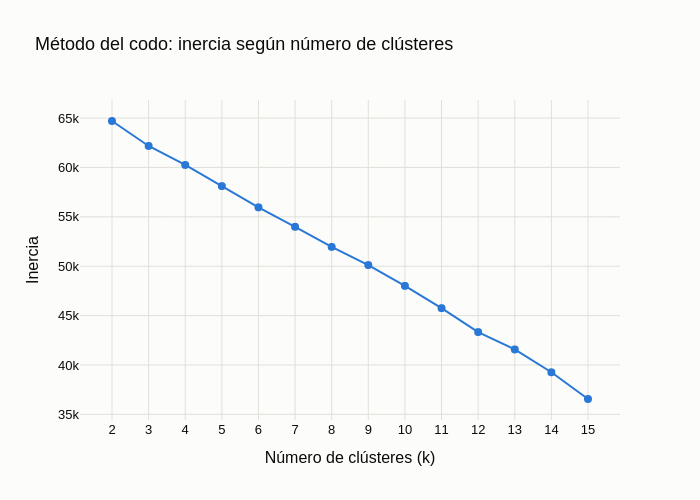

In [37]:
from sklearn.cluster import KMeans

inercias = []
rango_k = range(2, 16)

for k in rango_k:
    kmeans_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_prueba.fit(X_escalado)
    inercias.append(kmeans_prueba.inertia_)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(rango_k), y=inercias,
    mode='lines+markers',
    line=dict(color='#2a78d6'),
    marker=dict(size=8),
))
fig.update_layout(
    title='Método del codo: inercia según número de clústeres',
    xaxis_title='Número de clústeres (k)',
    yaxis_title='Inercia',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_xaxes(gridcolor='#e1e0d9', dtick=1)
fig.update_yaxes(gridcolor='#e1e0d9')
fig.show()

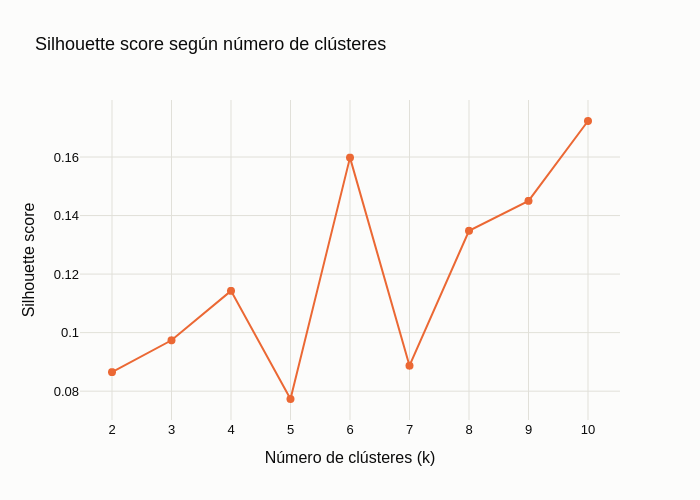

In [38]:
from sklearn.metrics import silhouette_score

silhouettes = []
rango_k_sil = range(2, 11)

for k in rango_k_sil:
    kmeans_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_prueba = kmeans_prueba.fit_predict(X_escalado)
    silhouettes.append(silhouette_score(X_escalado, etiquetas_prueba))

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(rango_k_sil), y=silhouettes,
    mode='lines+markers',
    line=dict(color='#eb6834'),
    marker=dict(size=8),
))
fig.update_layout(
    title='Silhouette score según número de clústeres',
    xaxis_title='Número de clústeres (k)',
    yaxis_title='Silhouette score',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
)
fig.update_xaxes(gridcolor='#e1e0d9', dtick=1)
fig.update_yaxes(gridcolor='#e1e0d9')
fig.show()

In [39]:
import numpy as np
import pandas as pd

kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_escalado)

etiquetas_kmeans = np.empty(len(y), dtype=object)
for i in range(7):
    mascara = (clusters == i)
    etiquetas_kmeans[mascara] = pd.Series(y[mascara]).mode()[0]

accuracy_kmeans = accuracy_score(y, etiquetas_kmeans)
print(f"Accuracy K-Means (tras reasignar clústeres a rol mayoritario): {accuracy_kmeans:.4f} ({accuracy_kmeans*100:.2f}%)")

Accuracy K-Means (tras reasignar clústeres a rol mayoritario): 0.2695 (26.95%)


In [40]:
baseline_mayoritario = y.value_counts(normalize=True).max()
print(f"Baseline (predecir siempre el rol mayoritario): {baseline_mayoritario:.4f} ({baseline_mayoritario*100:.2f}%)")

Baseline (predecir siempre el rol mayoritario): 0.2557 (25.57%)


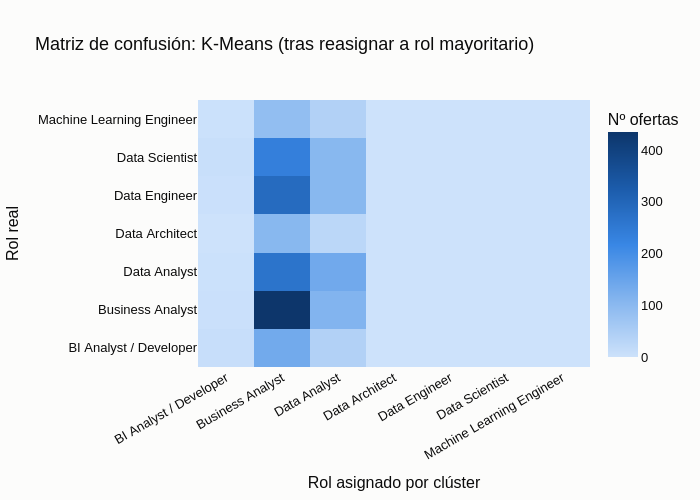

In [41]:
etiquetas_roles = sorted(y.unique())
matriz_confusion_kmeans = confusion_matrix(y, etiquetas_kmeans, labels=etiquetas_roles)
matriz_confusion_kmeans_df = pd.DataFrame(matriz_confusion_kmeans, index=etiquetas_roles, columns=etiquetas_roles)

fig = go.Figure(data=go.Heatmap(
    z=matriz_confusion_kmeans_df.values,
    x=matriz_confusion_kmeans_df.columns,
    y=matriz_confusion_kmeans_df.index,
    colorscale=colorscale_azul,
    colorbar=dict(title='Nº ofertas'),
    hovertemplate='Real: %{y}<br>Clúster reasignado: %{x}<br>%{z} ofertas<extra></extra>',
))

fig.update_layout(
    title='Matriz de confusión: K-Means (tras reasignar a rol mayoritario)',
    xaxis_title='Rol asignado por clúster',
    yaxis_title='Rol real',
    plot_bgcolor='#fcfcfb',
    paper_bgcolor='#fcfcfb',
    font=dict(color='#0b0b0b', size=13),
    margin=dict(l=180, b=120),
)
fig.update_xaxes(tickangle=-30)
fig.show()

Varianza explicada por las 2 componentes: 12.46%


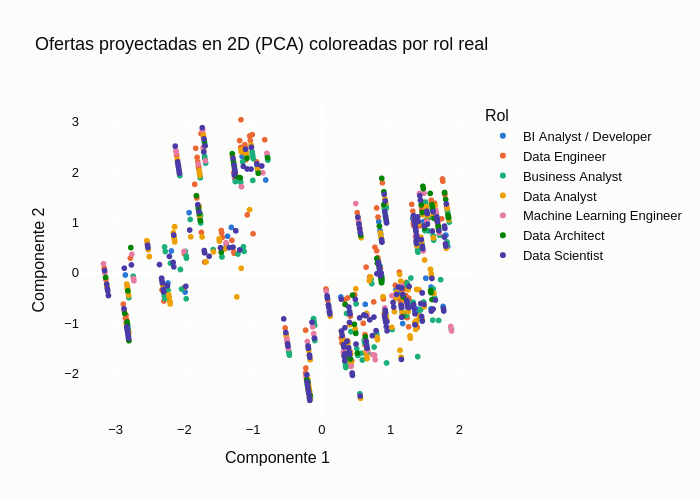

In [42]:
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_escalado)

print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

paleta_roles = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7']

fig = px.scatter(
    x=X_pca[:, 0], y=X_pca[:, 1],
    color=y,
    color_discrete_sequence=paleta_roles,
    title='Ofertas proyectadas en 2D (PCA) coloreadas por rol real',
    labels={'x': 'Componente 1', 'y': 'Componente 2', 'color': 'Rol'},
)
fig.update_layout(plot_bgcolor='#fcfcfb', paper_bgcolor='#fcfcfb', font=dict(color='#0b0b0b', size=13))
fig.show()

## 5️⃣ Qué reveló K-Means: el perfil de cada clúster
En vez de quedarnos en que los clústeres no coinciden con los roles, perfilamos cada uno para ver qué segmentación real del mercado encontró el algoritmo.

In [43]:
df['cluster_kmeans'] = clusters

resumen_clusters = df.groupby('cluster_kmeans').agg(
    num_ofertas=('cluster_kmeans', 'size'),
    industria_principal=('industria_principal', lambda x: x.mode()[0]),
    modalidad_remoto=('modalidad_remoto', lambda x: x.mode()[0]),
    experiencia_principal=('formatted_experience_level', lambda x: x.mode()[0]),
    num_skills_media=('num_skills', 'mean'),
).round(2)

resumen_clusters

,num_ofertas,industria_principal,modalidad_remoto,experiencia_principal,num_skills_media
cluster_kmeans,,,,,
0,63,Banking,No especificado,Mid-Senior level,4.68
1,324,Otras,No especificado,Mid-Senior level,4.02
2,554,IT Services and IT Consulting,Remoto,Mid-Senior level,4.23
3,1105,IT Services and IT Consulting,No especificado,Mid-Senior level,4.03
4,30,Telecommunications,No especificado,Mid-Senior level,3.80
5,66,Insurance,No especificado,Mid-Senior level,3.77
6,21,Defense and Space Manufacturing,No especificado,Mid-Senior level,3.71


In [44]:
tabla_cluster_rol = pd.crosstab(df['cluster_kmeans'], df['categoria_rol'], normalize='index').round(3) * 100
tabla_cluster_rol

categoria_rol,BI Analyst / Developer,Business Analyst,Data Analyst,Data Architect,Data Engineer,Data Scientist,Machine Learning Engineer
cluster_kmeans,,,,,,,
0,4.8,27.0,22.2,19.0,19.0,4.8,3.2
1,10.5,27.2,20.7,4.6,15.7,16.0,5.2
2,7.6,20.2,24.0,4.9,18.8,17.9,6.7
3,8.1,28.2,15.7,6.6,19.6,15.5,6.2
4,30.0,13.3,10.0,0.0,13.3,23.3,10.0
5,15.2,27.3,18.2,7.6,12.1,16.7,3.0
6,0.0,9.5,28.6,4.8,4.8,28.6,23.8


In [45]:
df.columns.tolist()

['job_id',
 'title',
 'categoria_rol',
 'description',
 'skills_desc',
 'formatted_work_type',
 'formatted_experience_level',
 'remote_allowed',
 'location',
 'views',
 'applies',
 'fecha_publicacion',
 'empresa',
 'company_size',
 'empresa_estado',
 'empresa_pais',
 'employee_count',
 'follower_count',
 'skills_lista',
 'industrias_lista',
 'beneficios_lista',
 'min_salary',
 'med_salary',
 'max_salary',
 'pay_period',
 'currency',
 'modalidad_remoto',
 'factor_anual',
 'salario_min_anual',
 'salario_max_anual',
 'descripcion_limpia',
 'skills_detectadas',
 'num_skills',
 'industria_principal',
 'salario_mediana_oferta',
 'cluster_kmeans']

In [46]:
# CSV principal: una fila por oferta
columnas_dashboard = [
    'job_id', 'title', 'categoria_rol', 'formatted_work_type',
    'formatted_experience_level', 'modalidad_remoto', 'location',
    'empresa', 'company_size', 'employee_count', 'follower_count',
    'industria_principal', 'views', 'applies', 'fecha_publicacion',
    'salario_min_anual', 'salario_max_anual', 'salario_mediana_oferta',
    'num_skills', 'cluster_kmeans'
]

df_dashboard = df[columnas_dashboard].copy()
df_dashboard.to_csv('vista_maestra_dashboard.csv', index=False)
print("Vista maestra:", df_dashboard.shape)
df_dashboard.head()

Vista maestra: (2163, 20)


,job_id,title,categoria_rol,formatted_work_type,formatted_experience_level,modalidad_remoto,location,empresa,company_size,employee_count,follower_count,industria_principal,views,applies,fecha_publicacion,salario_min_anual,salario_max_anual,salario_mediana_oferta,num_skills,cluster_kmeans
0,3891822840,Business Intelligence Analyst,BI Analyst / Developer,Full-time,Mid-Senior level,No especificado,"Los Angeles, CA",BIGO,5,2800,136918,Software Development,5.0,NaN,2024-04-12,NaN,NaN,NaN,4,3
1,3901982014,Business Intelligence Intern,BI Analyst / Developer,Full-time,No especificado,No especificado,"Fort Smith, AR",Kopco,3,28,195,Manufacturing,3.0,1.0,2024-04-18,NaN,NaN,NaN,0,3
2,3891074414,"Sr Data engineer with AWS, PYTHON (W2)",Data Engineer,Contract,No especificado,Remoto,United States,4A IT Services LLC,1,7,1795,IT Services and IT Consulting,3.0,NaN,2024-04-11,NaN,NaN,NaN,5,2
3,3904970103,Public Markets Business Analyst,Business Analyst,Contract,No especificado,Remoto,United States,Vertiscript Global,1,16,1457,IT Services and IT Consulting,57.0,NaN,2024-04-18,NaN,NaN,NaN,1,2
4,3904957834,Data Analyst,Data Analyst,Full-time,Entry level,Remoto,New York City Metropolitan Area,Coders Data,3,249,102713,IT Services and IT Consulting,10.0,3.0,2024-04-18,NaN,NaN,NaN,0,2


In [47]:
# CSV de skills: una fila por cada combinación oferta-skill
df_skills = df[['job_id', 'skills_detectadas']].explode('skills_detectadas')
df_skills = df_skills.rename(columns={'skills_detectadas': 'skill'})
df_skills = df_skills.dropna(subset=['skill'])
df_skills.to_csv('oferta_skills.csv', index=False)
print("Oferta-skill:", df_skills.shape)
df_skills.head(10)

Oferta-skill: (8828, 2)


,job_id,skill
0,3891822840,Python
0,3891822840,SQL
0,3891822840,R
0,3891822840,Excel
2,3891074414,Python
2,3891074414,Java
2,3891074414,Scala
2,3891074414,AWS
2,3891074414,ETL
3,3904970103,SAP


In [48]:
# Descargar ambos archivos a tu ordenador
from google.colab import files
files.download('vista_maestra_dashboard.csv')
files.download('oferta_skills.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# Exportamos como Excel en vez de CSV: evita cualquier ambigüedad de formato de número
!pip install -q openpyxl

df_dashboard.to_excel('vista_maestra_dashboard.xlsx', index=False, engine='openpyxl')
df_skills.to_excel('oferta_skills.xlsx', index=False, engine='openpyxl')

from google.colab import files
files.download('vista_maestra_dashboard.xlsx')
files.download('oferta_skills.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6️⃣ Productivización: recomendador de rol y skills

Con el modelo ya validado en las secciones anteriores, esta última sección lo convierte en una herramienta reutilizable: se guarda el modelo entrenado a disco (`modelo_rol.pkl` + `vectorizador_rol.pkl`) y se construye una función que, dado el perfil de una persona (industria de interés, modalidad, nivel de experiencia y skills que ya tiene), devuelve los roles más accesibles ordenados por probabilidad y las skills que le faltan para el rol mejor puntuado.

In [50]:
modelo_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo_final.fit(X, y)

print("Modelo final entrenado con", X.shape[0], "ofertas")

Modelo final entrenado con 2163 ofertas


In [51]:
import joblib

joblib.dump(modelo_final, 'modelo_rol.pkl')
joblib.dump(vectorizador, 'vectorizador_rol.pkl')

from google.colab import files
files.download('modelo_rol.pkl')
files.download('vectorizador_rol.pkl')

print("Guardados correctamente")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Guardados correctamente


In [52]:
skills_por_rol = df[['categoria_rol', 'skills_detectadas']].explode('skills_detectadas').dropna(subset=['skills_detectadas'])

top_skills_por_rol = (
    skills_por_rol.groupby('categoria_rol')['skills_detectadas']
    .apply(lambda x: x.value_counts().head(10).index.tolist())
    .to_dict()
)

for rol, skills in top_skills_por_rol.items():
    print(f"{rol}: {skills}")

BI Analyst / Developer: ['SQL', 'Power BI', 'Tableau', 'ETL', 'Python', 'Excel', 'DAX', 'Azure', 'R', 'Agile']
Business Analyst: ['Agile', 'Excel', 'SQL', 'Jira', 'Scrum', 'Power BI', 'Tableau', 'Salesforce', 'Python', 'SAP']
Data Analyst: ['SQL', 'Excel', 'Python', 'Tableau', 'Power BI', 'Agile', 'R', 'Machine Learning', 'Java', 'C++']
Data Architect: ['SQL', 'Azure', 'ETL', 'Snowflake', 'Python', 'AWS', 'Spark', 'Agile', 'Databricks', 'Google Cloud']
Data Engineer: ['SQL', 'Python', 'AWS', 'Azure', 'Spark', 'ETL', 'Agile', 'Java', 'Scala', 'Snowflake']
Data Scientist: ['Python', 'Machine Learning', 'SQL', 'R', 'AWS', 'Spark', 'Deep Learning', 'Tableau', 'Scala', 'Google Cloud']
Machine Learning Engineer: ['Machine Learning', 'Python', 'Deep Learning', 'AWS', 'Spark', 'Java', 'SQL', 'Google Cloud', 'Scikit-learn', 'Azure']


### Probando la herramienta con dos perfiles distintos

Para comprobar que la recomendación responde de forma coherente al perfil de entrada, se prueba con dos casos con propósito: un perfil de entrada al sector (nivel Entry, pocas skills, background no técnico) y un perfil senior con varias skills técnicas de peso — buscando que el modelo no dé siempre la misma respuesta, sino que reaccione al dato de entrada.

In [53]:
def recomendar_rol(industria_principal, modalidad_remoto, formatted_experience_level, skills_actuales):
    """
    skills_actuales: lista de skills que la persona ya tiene, ej. ['SQL', 'Excel', 'Python']
    """
    num_skills = len(skills_actuales)

    perfil = {
        'industria_principal': industria_principal,
        'modalidad_remoto': modalidad_remoto,
        'formatted_experience_level': formatted_experience_level,
        'num_skills': num_skills
    }

    X_perfil = vectorizador.transform([perfil])
    probabilidades = modelo_final.predict_proba(X_perfil)[0]

    ranking = sorted(zip(modelo_final.classes_, probabilidades), key=lambda x: x[1], reverse=True)

    rol_top = ranking[0][0]
    skills_del_rol = top_skills_por_rol[rol_top]
    skills_que_faltan = [s for s in skills_del_rol if s not in skills_actuales]

    print(f"Roles más accesibles para este perfil:")
    for rol, prob in ranking:
        print(f"  {rol}: {prob*100:.1f}%")

    print(f"\nPara acercarte más a '{rol_top}', las skills que más te faltan son:")
    print(f"  {skills_que_faltan[:5]}")

    return ranking, skills_que_faltan

# Prueba con un perfil de ejemplo
recomendar_rol(
    industria_principal='IT Services and IT Consulting',
    modalidad_remoto='Remoto',
    formatted_experience_level='Entry level',
    skills_actuales=['Excel', 'SAP']
)

Roles más accesibles para este perfil:
  Data Analyst: 77.6%
  Business Analyst: 10.5%
  Data Architect: 4.5%
  BI Analyst / Developer: 3.9%
  Data Scientist: 2.5%
  Data Engineer: 1.0%
  Machine Learning Engineer: 0.0%

Para acercarte más a 'Data Analyst', las skills que más te faltan son:
  ['SQL', 'Python', 'Tableau', 'Power BI', 'Agile']


([('Data Analyst', np.float64(0.7759179403486988)),
  ('Business Analyst', np.float64(0.10502172057672825)),
  ('Data Architect', np.float64(0.044835884231514356)),
  ('BI Analyst / Developer', np.float64(0.03930859464759555)),
  ('Data Scientist', np.float64(0.025069902797111854)),
  ('Data Engineer', np.float64(0.009845957398351236)),
  ('Machine Learning Engineer', np.float64(0.0))],
 ['SQL',
  'Python',
  'Tableau',
  'Power BI',
  'Agile',
  'R',
  'Machine Learning',
  'Java',
  'C++'])

In [54]:
# Segundo perfil de prueba: senior, técnico, muchas skills
recomendar_rol(
    industria_principal='Financial Services',
    modalidad_remoto='No especificado',
    formatted_experience_level='Mid-Senior level',
    skills_actuales=['Python', 'SQL', 'Machine Learning', 'AWS', 'Spark', 'Deep Learning', 'Scikit-learn']
)

Roles más accesibles para este perfil:
  Data Scientist: 63.8%
  Data Architect: 18.9%
  Data Engineer: 14.1%
  Data Analyst: 1.6%
  Machine Learning Engineer: 1.1%
  BI Analyst / Developer: 0.2%
  Business Analyst: 0.2%

Para acercarte más a 'Data Scientist', las skills que más te faltan son:
  ['R', 'Tableau', 'Scala', 'Google Cloud']


([('Data Scientist', np.float64(0.6384191426847662)),
  ('Data Architect', np.float64(0.18923665689793234)),
  ('Data Engineer', np.float64(0.14137182231796402)),
  ('Data Analyst', np.float64(0.015866190102140198)),
  ('Machine Learning Engineer', np.float64(0.010656798363901926)),
  ('BI Analyst / Developer', np.float64(0.0024182716992849768)),
  ('Business Analyst', np.float64(0.0020311179340103723))],
 ['R', 'Tableau', 'Scala', 'Google Cloud'])